In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

In [4]:
df=pd.read_csv('dataset_reducido.csv')

In [5]:
print("informacion del dataset")
df.info()

informacion del dataset
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   protocol_type  10000 non-null  str  
 1   service        10000 non-null  str  
 2   duration       10000 non-null  int64
 3   src_bytes      10000 non-null  int64
 4   dst_bytes      10000 non-null  int64
 5   logged_in      10000 non-null  int64
 6   count          10000 non-null  int64
 7   target         10000 non-null  str  
dtypes: int64(5), str(3)
memory usage: 767.1 KB


In [6]:
print('valores nulos')
print(df.isnull().sum())

valores nulos
protocol_type    0
service          0
duration         0
src_bytes        0
dst_bytes        0
logged_in        0
count            0
target           0
dtype: int64


In [7]:
display(df.describe())

,duration,src_bytes,dst_bytes,logged_in,count
count,10000.00000,1.000000e+04,1.000000e+04,10000.000000,10000.000000
mean,303.57040,1.111772e+04,2.878036e+03,0.394100,83.973800
std,2625.60665,2.581551e+05,7.440287e+04,0.488681,115.237395
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,2.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,14.000000
75%,0.00000,2.680000e+02,4.640000e+02,1.000000,141.000000
max,42492.00000,1.882898e+07,5.153771e+06,1.000000,511.000000


In [8]:
# Separamos la variable objetivo (target) de las variables predictoras
X = df.drop(columns=['target'])
y = df['target']

In [9]:
# Convertimos las columnas de texto a binario (0 y 1)
X_encoded = pd.get_dummies(X, columns=['protocol_type', 'service'], drop_first=False)

In [10]:
from sklearn.preprocessing import StandardScaler

# Creamos el objeto escalador
scaler = StandardScaler()

# Ajustamos el escalador con los datos y los transformamos
X_scaled = scaler.fit_transform(X_encoded)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(max_depth=5, min_samples_split=20, random_state=42)
modelo_rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, min_samples_split=20, random_state=42)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = modelo_rf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      ataque       0.98      0.95      0.97       929
      normal       0.96      0.99      0.97      1071

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000



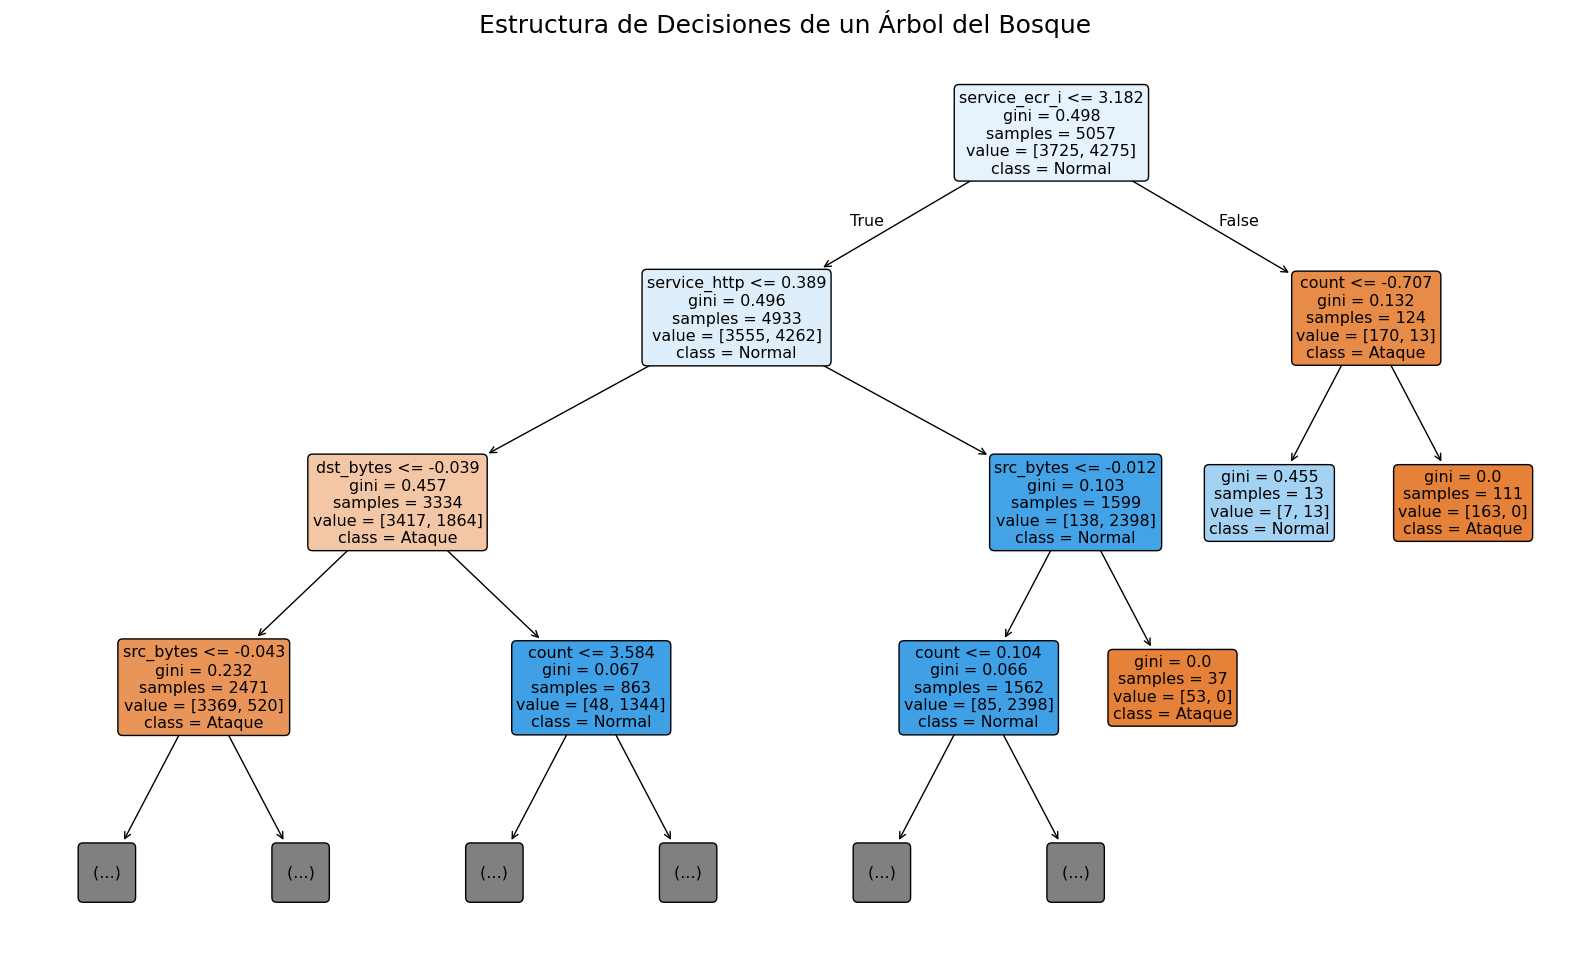

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 12))

plot_tree(
    modelo_rf.estimators_[0], 
    feature_names=X_encoded.columns, 
    class_names=['Ataque', 'Normal'], 
    filled=True, 
    max_depth=3,  
    rounded=True
)

plt.title("Estructura de Decisiones de un Árbol del Bosque", fontsize=18)
plt.show()

Reporte de Clasificación del Modelo Optimizado:
              precision    recall  f1-score   support

      ataque       0.98      0.95      0.97       929
      normal       0.96      0.99      0.97      1071

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000



<Figure size 600x600 with 0 Axes>

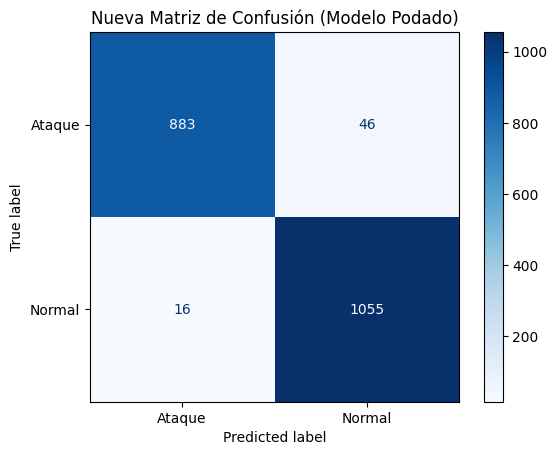

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. El modelo optimizado hace el examen
y_pred = modelo_rf.predict(X_test)

# 2. Imprimir el reporte de métricas en texto (donde sale el Accuracy)
print("Reporte de Clasificación del Modelo Optimizado:")
print(classification_report(y_test, y_pred))

# 3. Calcular y graficar la nueva Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ataque', 'Normal'])

# Dibujamos el gráfico con colores agradables
plt.figure(figsize=(6, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Nueva Matriz de Confusión (Modelo Podado)")
plt.show()

In [16]:
from sklearn.metrics import accuracy_score

# Calculamos el porcentaje general de aciertos
exactitud = accuracy_score(y_test, y_pred)
print(f"El Accuracy de nuestro modelo optimizado es: {exactitud * 100:.2f}%")

El Accuracy de nuestro modelo optimizado es: 96.90%


In [17]:
import os
import joblib

# 1. Aseguramos que exista la carpeta 'models'
os.makedirs('models', exist_ok=True)

# 2. Empaquetamos el nuevo modelo optimizado, el escalador y las columnas
artefactos_optimizados = {
    'modelo': modelo_rf,
    'scaler': scaler,
    'columnas': X_encoded.columns
}

# 3. Guardamos todo en el archivo .pkl
joblib.dump(artefactos_optimizados, 'models/modelo_completo.pkl')
print("¡Felicidades! 'models/modelo_completo.pkl' guardado y listo para producción.")

¡Felicidades! 'models/modelo_completo.pkl' guardado y listo para producción.
